In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde
from util import *

In [2]:
current_dir = Path().resolve()
scale_E = 1
scale_I = 2/5

#data_directory = current_dir.parent / 'data'
file_path = current_dir.parent / 'data/mpox_2022_paper/population.csv'
population = pd.read_csv(file_path)
degrees_real = population["SEX_PARTNERS_MALE_ANAL_UNCODED"]/12
n = len(degrees_real)

file_path = current_dir.parent / 'data/berlin_mpox_all.csv'
berlin_mpox_all = pd.read_csv(file_path)

berlin_mpox_all = berlin_mpox_all[berlin_mpox_all['start_date_week'] <= "2022-10-31"]

vacc1_t = berlin_mpox_all["first_dosis"].values
vacc2_t = berlin_mpox_all["second_dosis"].values
imports_t = berlin_mpox_all["imports_reported"].values
data = berlin_mpox_all["reported_cases"].values#/len(degrees_real)
t = np.arange(len(data))
t_label = pd.to_datetime(berlin_mpox_all["start_date_week"], format="%Y-%m-%d")

# Run1

In [3]:
# create file for gridsearch of beta and diag 
beta = np.linspace(0.1, 4.0, 100)
diag = np.linspace(5/2 * ((1- 0.18)**(-1/5) -1), 5/2 * ((1- 0.4)**(-1/5) -1), 100)
print(diag)

combined = [(f,s) for f in beta for s in diag]

df_tmp = pd.DataFrame(combined, columns=["beta", "diag"])
df_tmp["seed"] = np.arange(10000)
print(df_tmp)


file_path = current_dir.parent / 'inputs/model2022/run1.csv'
df_tmp.to_csv(file_path)

[0.10122092 0.10291481 0.1046087  0.10630259 0.10799647 0.10969036
 0.11138425 0.11307814 0.11477203 0.11646591 0.1181598  0.11985369
 0.12154758 0.12324147 0.12493536 0.12662924 0.12832313 0.13001702
 0.13171091 0.1334048  0.13509869 0.13679257 0.13848646 0.14018035
 0.14187424 0.14356813 0.14526202 0.1469559  0.14864979 0.15034368
 0.15203757 0.15373146 0.15542534 0.15711923 0.15881312 0.16050701
 0.1622009  0.16389479 0.16558867 0.16728256 0.16897645 0.17067034
 0.17236423 0.17405812 0.175752   0.17744589 0.17913978 0.18083367
 0.18252756 0.18422145 0.18591533 0.18760922 0.18930311 0.190997
 0.19269089 0.19438477 0.19607866 0.19777255 0.19946644 0.20116033
 0.20285422 0.2045481  0.20624199 0.20793588 0.20962977 0.21132366
 0.21301755 0.21471143 0.21640532 0.21809921 0.2197931  0.22148699
 0.22318088 0.22487476 0.22656865 0.22826254 0.22995643 0.23165032
 0.2333442  0.23503809 0.23673198 0.23842587 0.24011976 0.24181365
 0.24350753 0.24520142 0.24689531 0.2485892  0.25028309 0.251976

Run the following command but in batches in parallel:
```
python scripts/stochastic_model/abc_smc.py 0 10000 model2022 run1
```
To collect batch results and combine them into one:
```
python scripts/collect_results.py model2022 1

In [4]:
file_path = current_dir.parent / 'results/model2022/result1.csv'
results = pd.read_csv(file_path)
print(results)
combined = pd.merge(df_tmp, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance'], ascending=True)
len(combined)

      index     distance  distance_cum
0         0   449.033406   5814.980481
1         1   446.448205   5783.964730
2         2   449.491935   5809.376128
3         3   449.733254   5812.381870
4         4   449.018931   5799.956121
...     ...          ...           ...
9995   9995  1422.240838  16725.509110
9996   9996  1420.183439  16637.050610
9997   9997  1377.213128  16438.325249
9998   9998  1458.557507  16716.709186
9999   9999  1445.866176  17055.887781

[10000 rows x 3 columns]


10000

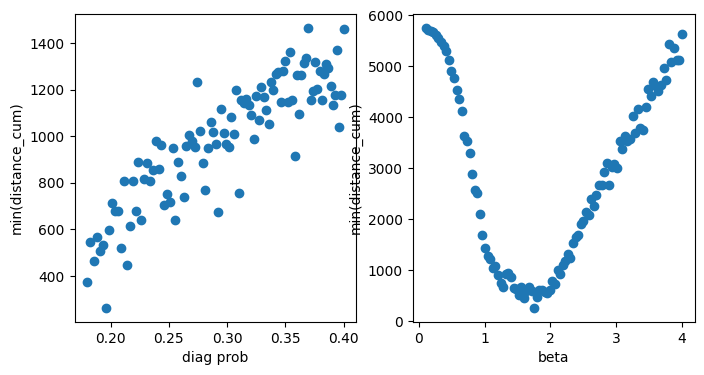

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
# diag 
combined["diag_prob"] = 1 - ((5/2)/(5/2 + combined["diag"]))**5
idx = combined.groupby("diag_prob")["distance_cum"].idxmin()
df_min = combined.loc[idx].sort_values("diag_prob")   # or sort by distance_cum
ax[0].scatter(df_min["diag_prob"], df_min["distance_cum"])
ax[0].set_xlabel("diag prob")
ax[0].set_ylabel("min(distance_cum)")
# beta
idx = combined.groupby("beta")["distance_cum"].idxmin()
df_min = combined.loc[idx].sort_values("beta")   # or sort by distance_cum
ax[1].scatter(df_min["beta"], df_min["distance_cum"])
ax[1].set_xlabel("beta")
ax[1].set_ylabel("min(distance_cum)")
plt.show()

Quantiles:
[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5]
[213.06545941 276.49881999 306.37264888 334.11083483 353.36440115
 372.2045788  443.76514056]
Quantiles:
[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5]
[ 873.94893066 1280.26753058 1627.53373503 2042.46450324 2478.76182695
 2975.11489854 5314.80874535]


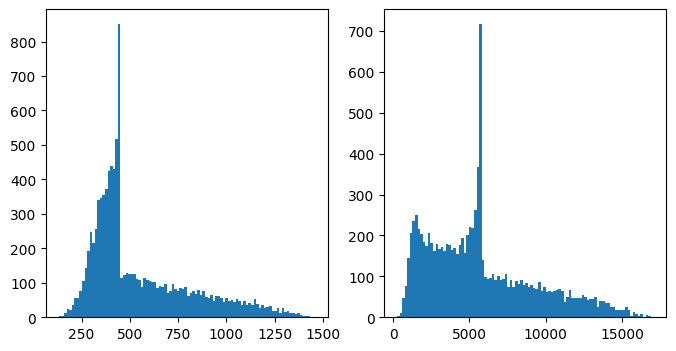

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# distribution of distance
ax[0].hist(combined['distance'], bins = 100)
print("Quantiles:")
print([0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5])
print(np.quantile(combined['distance'], [0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5]))

ax[1].hist(combined['distance_cum'], bins = 100)
print("Quantiles:")
print([0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5])
print(np.quantile(combined['distance_cum'], [0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5]))

55


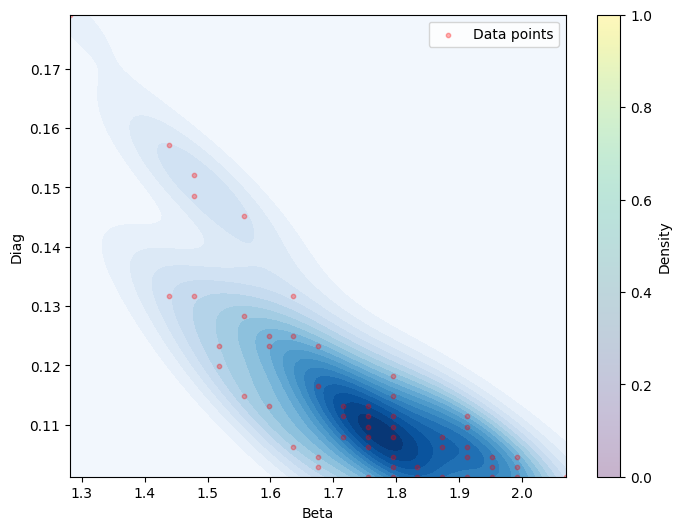

In [7]:
threshold = 250
threshold_cum = 750
accepted_params = combined[(combined["distance"] <threshold)&(combined["distance_cum"] <threshold_cum)][["beta", "diag"]].values
print(len(accepted_params))
data = accepted_params.T


kde = gaussian_kde(data, bw_method='scott')  # 'scott' or 'silverman' can be used for bandwidth estimation


x_grid = np.linspace(np.min(data[0,:]), np.max(data[0,:]), 100)
y_grid = np.linspace(np.min(data[1,:]), np.max(data[1,:]), 100)
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])  # Positions must be a 2xN array

# Evaluate the KDE on the grid
density = kde(positions).reshape(X.shape)

# Plot the results
plt.figure(figsize=(8, 6))
plt.contourf(X, Y, density, levels=20, cmap='Blues')
plt.scatter(data[0], data[1], s=10, color='red', alpha=0.3, label='Data points')
plt.xlabel('Beta')
plt.ylabel('Diag')
plt.colorbar(label='Density')
plt.legend()
plt.show()

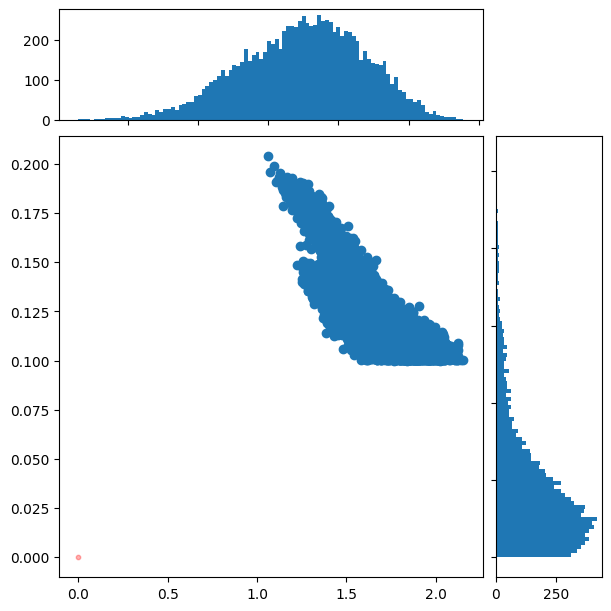

In [10]:
# Generating samples with constraints using rejection sampling
def constrained_sampling(kde, num_samples, constraint_func):
    samples = []
    while len(samples) < num_samples:
        # Draw more than needed to cover rejections
        new_samples = kde.resample(num_samples).T
        for sample in new_samples:
            if constraint_func(sample):
                samples.append(sample)
            if len(samples) >= num_samples:
                break
    return np.array(samples)

# Define a constraint function
def constraint_func(sample):
    return sample[1] > 0.1

num_samples = 10000
np.random.seed(7)
new_samples = constrained_sampling(kde, num_samples, constraint_func)

axs = scatter_hist(new_samples[:,0], new_samples[:,1])
axs["scatter"].scatter(data[0], data[1], s=10, color='red', alpha=0.3, label='Data points')

In [11]:
df_tmp = pd.DataFrame(new_samples, columns=["beta", "diag"])
df_tmp["seed"] = np.arange(10000)
print(df_tmp)

file_path = current_dir.parent / 'inputs/model2022/run2.csv'
df_tmp.to_csv(file_path, index = False)

          beta      diag  seed
0     1.487938  0.140943     0
1     1.870001  0.110177     1
2     1.666156  0.117898     2
3     1.626130  0.122869     3
4     1.828317  0.103394     4
...        ...       ...   ...
9995  1.621678  0.132919  9995
9996  1.531567  0.150604  9996
9997  1.794363  0.113039  9997
9998  1.886815  0.110651  9998
9999  1.708013  0.117612  9999

[10000 rows x 3 columns]


# Run2 

Run the following command but in batches in parallel:
```
python scripts/stochastic_model/abc_smc.py 0 10000 model2022 run2
```
To collect batch results and combine them into one:
```
python scripts/collect_results.py model2022 2

In [12]:
file_path = current_dir.parent / 'results/model2022/result2.csv'
results = pd.read_csv(file_path)

file_path = current_dir.parent / 'inputs/model2022/run2.csv'
df_tmp = pd.read_csv(file_path)
combined = pd.merge(df_tmp, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance'], ascending=True)
combined.head()

,beta,diag,seed,index,distance,distance_cum
633,1.829571,0.101570,633,633,88.803153,422.480769
6810,1.812529,0.103383,6810,6810,90.260733,113.017698
4056,1.962717,0.103608,4056,4056,90.691786,381.464284
7449,1.727311,0.110163,7449,7449,92.157474,132.143861
6874,1.742339,0.105935,6874,6874,93.418414,174.304332


Quantiles:
[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5]
[135.41048704 165.98478846 183.67498428 195.79798262 206.24499988
 214.28077373 249.20674147]
Quantiles:
[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5]
[410.51056979 531.52257369 605.32098907 656.05300768 696.98536031
 733.72695866 888.93897377]


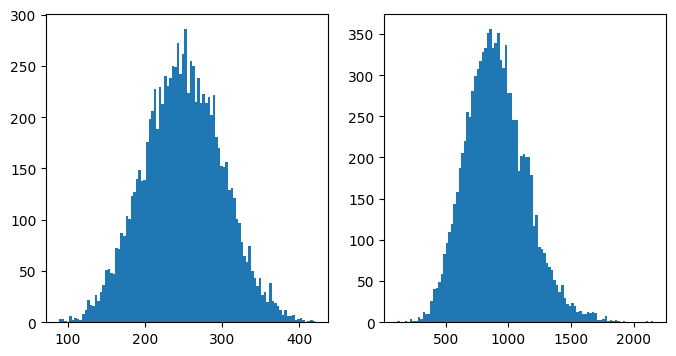

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# distribution of distance
ax[0].hist(combined['distance'], bins = 100)
print("Quantiles:")
print([0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5])
print(np.quantile(combined['distance'], [0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5]))

ax[1].hist(combined['distance_cum'], bins = 100)
print("Quantiles:")
print([0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5])
print(np.quantile(combined['distance_cum'], [0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5]))

71


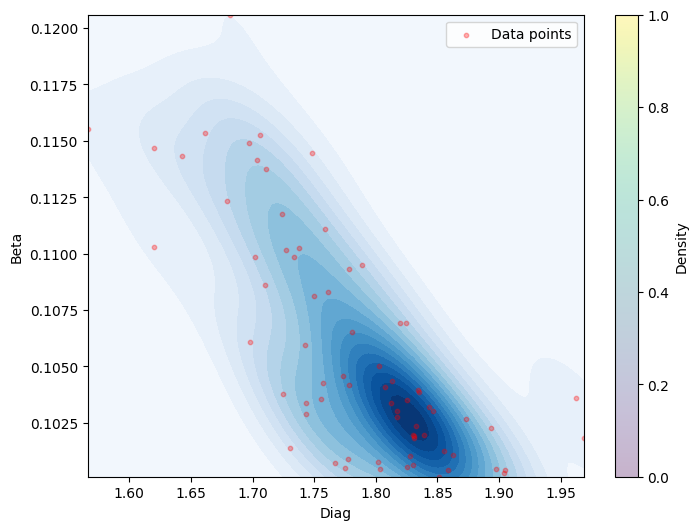

In [14]:
threshold = 150
threshold_cum = 400
accepted_params = combined[(combined["distance"] <threshold)&(combined["distance_cum"] <threshold_cum)][["beta", "diag"]].values
print(len(accepted_params))
data = accepted_params.T

kde = gaussian_kde(data, bw_method='scott')  # 'scott' or 'silverman' can be used for bandwidth estimation

x_grid = np.linspace(np.min(data[0,:]), np.max(data[0,:]), 100)
y_grid = np.linspace(np.min(data[1,:]), np.max(data[1,:]), 100)
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])  # Positions must be a 2xN array

# Evaluate the KDE on the grid
density = kde(positions).reshape(X.shape)

# Plot the results
plt.figure(figsize=(8, 6))
plt.contourf(X, Y, density, levels=20, cmap='Blues')
plt.scatter(data[0], data[1], s=10, color='red', alpha=0.3, label='Data points')
plt.xlabel('Diag')
plt.ylabel('Beta')
plt.colorbar(label='Density')
plt.legend()
plt.show()

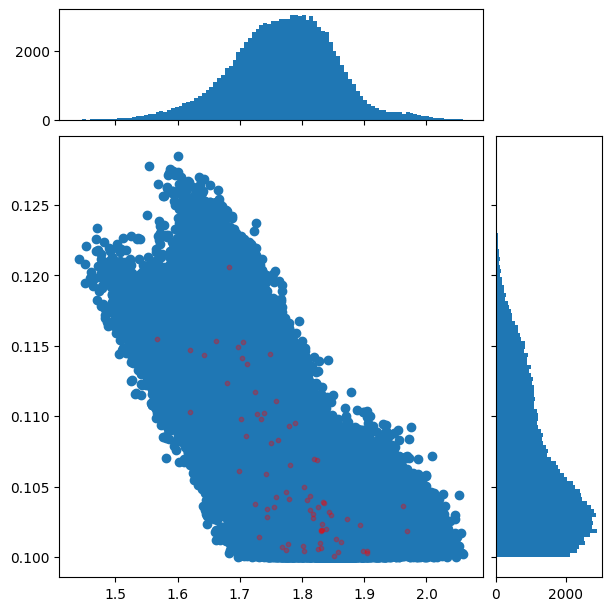

In [15]:
num_samples = 100000
np.random.seed(7)
new_samples = constrained_sampling(kde, num_samples, constraint_func)

axs = scatter_hist(new_samples[:,0], new_samples[:,1])
axs["scatter"].scatter(data[0], data[1], s=10, color='red', alpha=0.3, label='Data points')

In [16]:
df_tmp = pd.DataFrame(new_samples, columns=["beta", "diag"])
df_tmp["seed"] = np.arange(100000)
print(df_tmp)

file_path = current_dir.parent / 'inputs/model2022/run3.csv'
df_tmp.to_csv(file_path, index = False)

           beta      diag   seed
0      1.693125  0.106714      0
1      1.815770  0.103761      1
2      1.768090  0.108754      2
3      1.791577  0.104859      3
4      1.751121  0.108704      4
...         ...       ...    ...
99995  1.857958  0.104565  99995
99996  1.905694  0.101669  99996
99997  1.636547  0.117006  99997
99998  1.901726  0.106094  99998
99999  1.840160  0.102410  99999

[100000 rows x 3 columns]


# Run3

Run the following command but in batches in parallel:
```
python scripts/stochastic_model/abc_smc.py 0 10000 model2022 run3
```
To collect batch results and combine them into one:
```
python scripts/collect_results.py model2022 3

In [17]:
file_path = current_dir.parent / 'results/model2022/result3.csv'
results = pd.read_csv(file_path)

file_path = current_dir.parent / 'inputs/model2022/run3.csv'
df_tmp = pd.read_csv(file_path)
combined = pd.merge(df_tmp, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance_cum'], ascending=True)

print(combined.head())

           beta      diag   seed  index   distance  distance_cum
3894   1.754822  0.101393   3894   3894  59.899917     85.434185
39784  1.770116  0.102494  39784  39784  76.341339     94.503968
4691   1.791303  0.100938   4691   4691  61.741396    100.667770
9319   1.824804  0.101358   9319   9319  76.138033    101.336075
5207   1.819128  0.100936   5207   5207  82.686154    103.547091


Quantiles:
[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5]
[122.19648113 153.81482373 170.75098828 182.47739586 191.6731593
 199.5413491  231.03246525]
Quantiles:
[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5]
[319.24200761 435.07453384 499.04067969 543.6468063  579.79444633
 611.18205143 742.11589388]


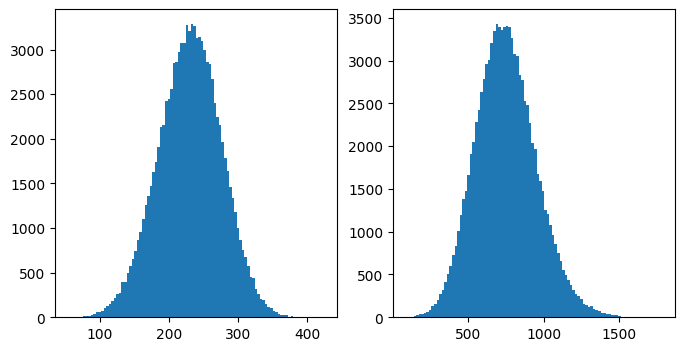

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# distribution of distance
ax[0].hist(combined['distance'], bins = 100)
print("Quantiles:")
print([0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5])
print(np.quantile(combined['distance'], [0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5]))

ax[1].hist(combined['distance_cum'], bins = 100)
print("Quantiles:")
print([0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5])
print(np.quantile(combined['distance_cum'], [0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.5]))

292


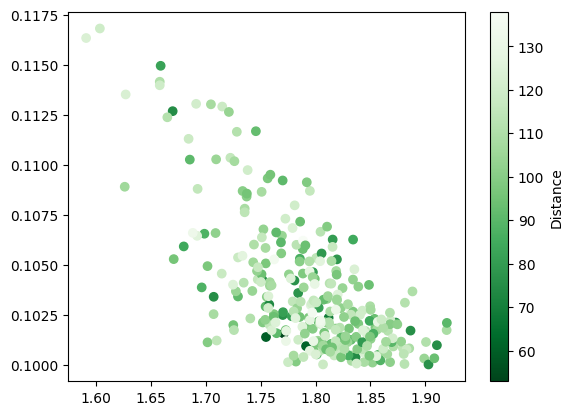

In [19]:
threshold = 150
threshold_cum = 250
accepted_params = combined[(combined["distance"] <threshold)&(combined["distance_cum"] <threshold_cum)]
print(len(accepted_params))

scatter = plt.scatter(accepted_params["beta"], accepted_params["diag"], c=accepted_params['distance'], cmap='Greens_r')
plt.colorbar(scatter, label='Distance')

In [20]:
accepted_params = accepted_params.sort_values(by=['distance'], ascending=True)
print(accepted_params.iloc[-1]["distance"], accepted_params.iloc[-1]["distance_cum"])
print(accepted_params.iloc[-1]["beta"], accepted_params.iloc[-1]["diag"], accepted_params.iloc[-1]["seed"])

137.97463535012514 237.00421937172345
1.7885859719597552 0.1062092448438262 32314.0


In [21]:
accepted_params = accepted_params.drop("index", axis = 1).reset_index(drop = True)
accepted_params

,beta,diag,seed,distance,distance_cum
0,1.771036,0.101567,49451,52.981129,142.460521
1,1.754822,0.101393,3894,59.899917,85.434185
2,1.791303,0.100938,4691,61.741396,100.667770
3,1.811855,0.102354,85886,68.593003,166.042163
4,1.757804,0.103017,79641,73.443856,218.064211
...,...,...,...,...,...
287,1.688164,0.106601,50345,132.634837,240.931526
288,1.804374,0.102220,51628,133.356665,242.059910
289,1.762288,0.105274,95380,134.859186,207.214864
290,1.796901,0.102620,25343,135.059246,244.855059


In [22]:
file_path = current_dir.parent / 'inputs/model2022/final_run.csv'
accepted_params.to_csv(file_path, index = False)

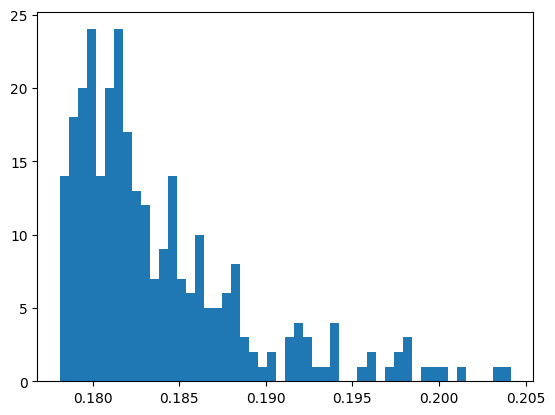

In [23]:
accepted_params["diag_prop"] = 1 - ((5/2)/(5/2 + accepted_params["diag"]))**5
plt.hist(accepted_params["diag_prop"], bins = 50)
plt.show()

In [24]:
accepted_params

,beta,diag,seed,distance,distance_cum,diag_prop
0,1.771036,0.101567,49451,52.981129,142.460521,0.180546
1,1.754822,0.101393,3894,59.899917,85.434185,0.180271
2,1.791303,0.100938,4691,61.741396,100.667770,0.179554
3,1.811855,0.102354,85886,68.593003,166.042163,0.181783
4,1.757804,0.103017,79641,73.443856,218.064211,0.182825
...,...,...,...,...,...,...
287,1.688164,0.106601,50345,132.634837,240.931526,0.188427
288,1.804374,0.102220,51628,133.356665,242.059910,0.181573
289,1.762288,0.105274,95380,134.859186,207.214864,0.186359
290,1.796901,0.102620,25343,135.059246,244.855059,0.182202
